In [ ]:
import pandas as pd


In [ ]:
dataset=pd.read_csv("/content/drive/MyDrive/Intellipaat-Jan2026/RNNs/AAPL_2006-01-01_to_2018-01-01.csv",index_col="Date",parse_dates=['Date'])

In [ ]:
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL


In [ ]:
dataset[:'2007-01-01']

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL
...,...,...,...,...,...,...
2006-12-22,11.92,12.01,11.66,11.74,153402130,AAPL
2006-12-26,11.74,11.80,11.56,11.64,122782926,AAPL
2006-12-27,11.16,11.71,10.97,11.65,485160788,AAPL


# Plot the high values of this stock.

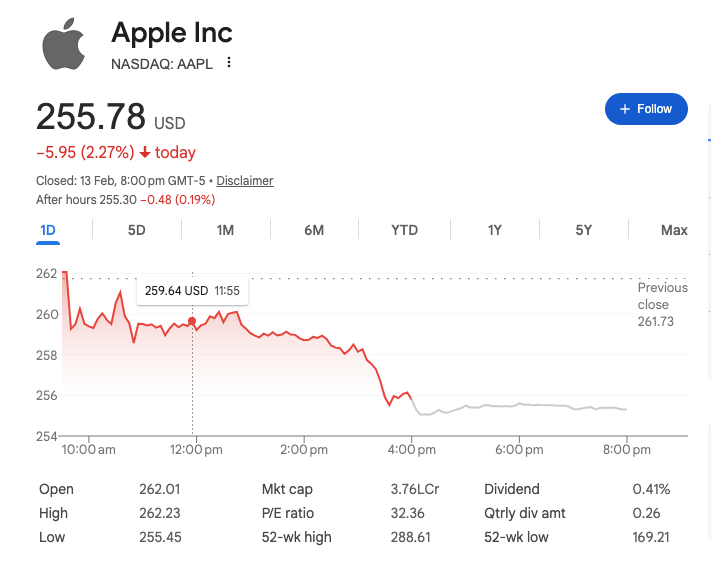

In [ ]:
from matplotlib import pyplot as plt

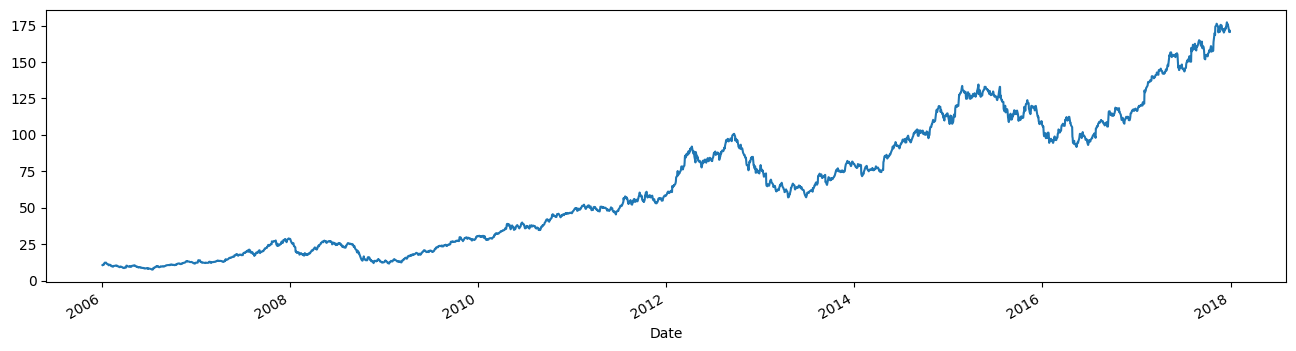

In [ ]:
# plot all the high values
dataset['High'].plot(figsize=(16,4))
plt.show()

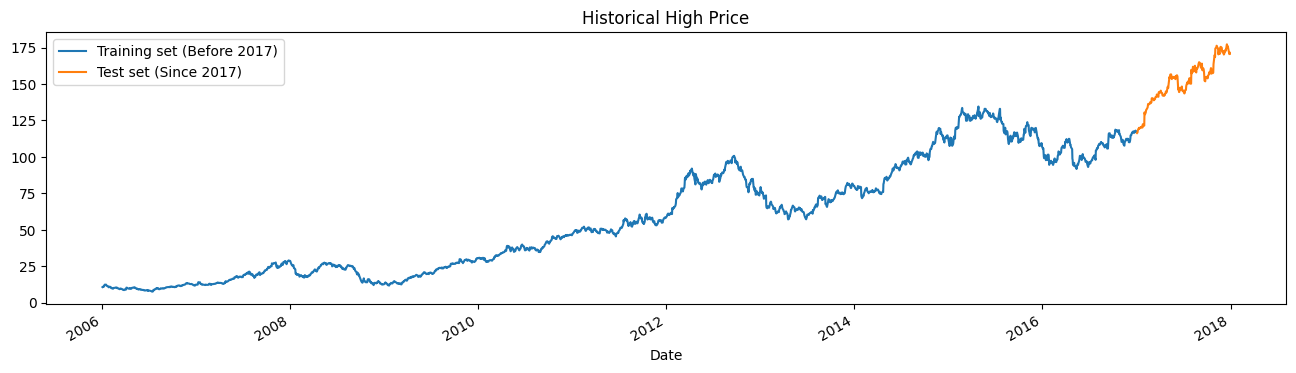

In [ ]:
# plot all the high values
dataset['High'][:'2016'].plot(figsize=(16,4), legend=True)
dataset['High']['2017':].plot(figsize=(16,4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (Since 2017)'])
plt.title('Historical High Price')
plt.show()

In [ ]:
# We will split the data into train and test
training_set=dataset[:'2016'].iloc[:,1:2].values
test_set=dataset['2017':].iloc[:,1:2].values


In [ ]:
training_set.shape, test_set.shape

((2768, 1), (251, 1))

In [ ]:
# Create the data for training
# [Look at previous 30 trading days] -> Current Day
training_set[:30]

array([[10.68],
       [10.85],
       [10.7 ],
       [10.96],
       [11.03],
       [11.7 ],
       [12.11],
       [12.34],
       [12.29],
       [12.34],
       [12.01],
       [11.67],
       [11.43],
       [11.37],
       [11.35],
       [11.07],
       [10.78],
       [10.51],
       [10.94],
       [10.91],
       [10.92],
       [10.77],
       [10.4 ],
       [10.36],
       [ 9.93],
       [ 9.87],
       [ 9.89],
       [ 9.67],
       [ 9.54],
       [ 9.73]])

In [ ]:
training_set[30]

array([9.95])

In [ ]:
# X_train -> predictors and target
# Sequential Data-> Whatever happened in the past (30 days of data)
# Try to predict what happened on the 31st

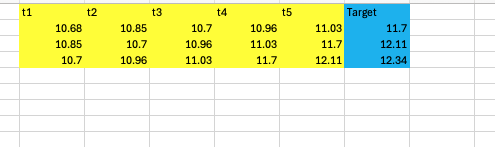

# Will start by 9:10, till then please complete the above task as discussed yesterday.

In [ ]:
X_train=[]
y_train=[]

X_test=[]
y_test=[]

In [ ]:
timesteps=30
for i in range(timesteps, len(training_set)):
  # print(i,i-timesteps)
  X_train.append(training_set[i-timesteps:i, 0])
  y_train.append(training_set[i,0])

0:5, 6th value in target
1:6, 7th value as target

timestep was 5
5-5:5 0:5
6-5:6 1:6

In [ ]:
timesteps=30
for i in range(timesteps, len(test_set)):
  # print(i,i-timesteps)
  X_test.append(test_set[i-timesteps:i, 0])
  y_test.append(test_set[i,0])

In [ ]:
for i in range(10):
  print("training Exaple: ",i+1)
  print(X_train[i], ":: ", y_train[i])


training Exaple:  1
[10.68 10.85 10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67
 11.43 11.37 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36
  9.93  9.87  9.89  9.67  9.54  9.73] ::  9.95
training Exaple:  2
[10.85 10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43
 11.37 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93
  9.87  9.89  9.67  9.54  9.73  9.95] ::  10.14
training Exaple:  3
[10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37
 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93  9.87
  9.89  9.67  9.54  9.73  9.95 10.14] ::  10.13
training Exaple:  4
[10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37 11.35
 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93  9.87  9.89
  9.67  9.54  9.73  9.95 10.14 10.13] ::  10.11
training Exaple:  5
[11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37 11.35 11.07
 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.

In [ ]:
for i in range(10):
  print("Test Exaple: ",i+1)
  print(X_test[i], ":: ", y_test[i])


Test Exaple:  1
[116.33 116.51 116.86 118.16 119.43 119.38 119.93 119.3  119.62 120.24
 120.5  120.09 120.45 120.81 120.1  122.1  122.44 122.35 121.63 121.39
 130.49 129.39 129.19 130.5  132.09 132.22 132.44 132.94 133.82 135.09] ::  136.27
Test Exaple:  2
[116.51 116.86 118.16 119.43 119.38 119.93 119.3  119.62 120.24 120.5
 120.09 120.45 120.81 120.1  122.1  122.44 122.35 121.63 121.39 130.49
 129.39 129.19 130.5  132.09 132.22 132.44 132.94 133.82 135.09 136.27] ::  135.9
Test Exaple:  3
[116.86 118.16 119.43 119.38 119.93 119.3  119.62 120.24 120.5  120.09
 120.45 120.81 120.1  122.1  122.44 122.35 121.63 121.39 130.49 129.39
 129.19 130.5  132.09 132.22 132.44 132.94 133.82 135.09 136.27 135.9 ] ::  135.83
Test Exaple:  4
[118.16 119.43 119.38 119.93 119.3  119.62 120.24 120.5  120.09 120.45
 120.81 120.1  122.1  122.44 122.35 121.63 121.39 130.49 129.39 129.19
 130.5  132.09 132.22 132.44 132.94 133.82 135.09 136.27 135.9  135.83] ::  136.75
Test Exaple:  5
[119.43 119.38 119.93 

In [ ]:
X_train=np.array(X_train)
X_test=np.array(X_test)
y_train=np.array(y_train)
y_test=np.array(y_test)

In [ ]:
from keras.layers

In [ ]:
# Lets create a simple ANN model
model=Sequential()
model.add()